### Model -1 for Home C (Simulated and Real Test Set)
#### Without hidden-dim layers

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]  

# Split the data into training and test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
# print("X_train shape:", X_train.shape)
# print("y_train shape:", y_train.shape)


X shape: (35040, 1380)
y shape: (35040,)


In [48]:
#  y_test

In [49]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32

input_layer = Input(shape=(input_dim,))
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(input_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
986/986 [==============================] - 5s 4ms/step - loss: 0.0114 - val_loss: 0.0090
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0065 - val_loss: 0.0029
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 7/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 8/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0015 - val_lo

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense_9 (Dense)             (None, 128)               176768    
                                                                 
 dense_10 (Dense)            (None, 64)                8256      
                                                                 
 dense_11 (Dense)            (None, 128)               8320      
                                                                 
 dense_12 (Dense)            (None, 1380)              178020    
                                                                 
Total params: 371,364
Trainable params: 371,364
Non-trainable params: 0
_________________________________________________________________
1095/1095 [==============================] - 4s 4ms/s

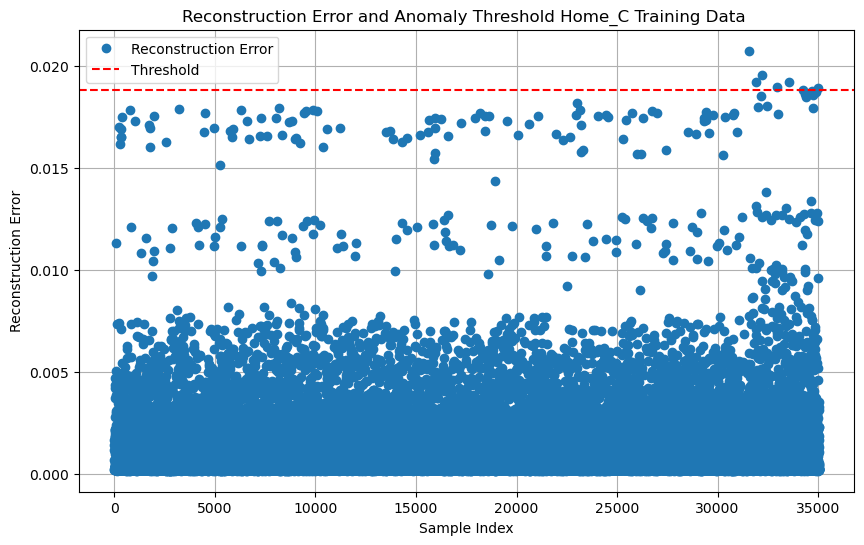

In [76]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (100 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold Home_C Training Data ')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_Training Data.png',bbox_inches='tight')
plt.show()


In [77]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)
#################################################

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

9/9 [==============================] - 0s 2ms/step
Threshold saved at: 0.018831217719807933
Anomalous Data Indices:
[157 163 173]


C:\Users\olufe\AppData\Local\Temp\ipykernel_24148\2881383620.py:24: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_24148\2881383620.py:25: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [78]:
# test_reconstruction_error

In [79]:
# y_test

In [80]:
# anomalies

In [81]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5340501792114696
Precision: 1.0
Recall: 0.022556390977443608
TNR: 1.0
FPR: 0.0
FNR: 0.9774436090225563
F1 Score: 0.04411764705882353
ROC AUC: 0.7681532598619837


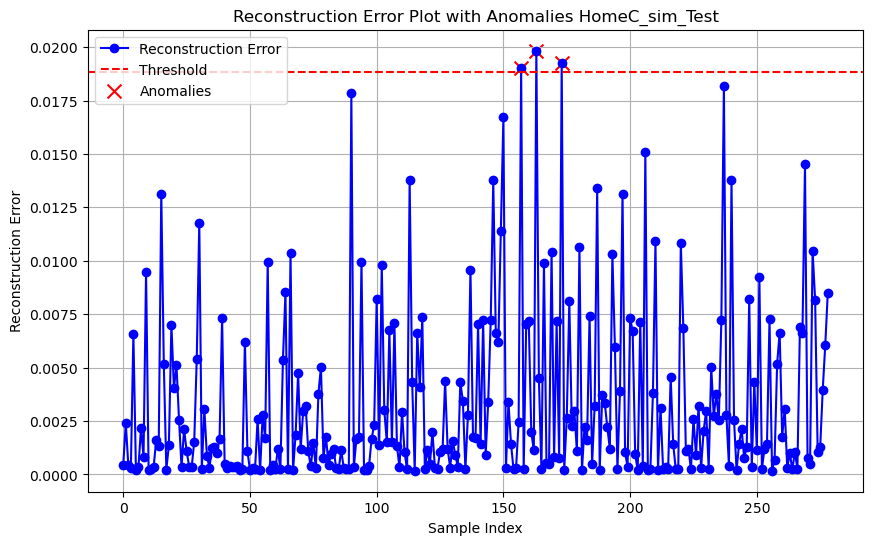

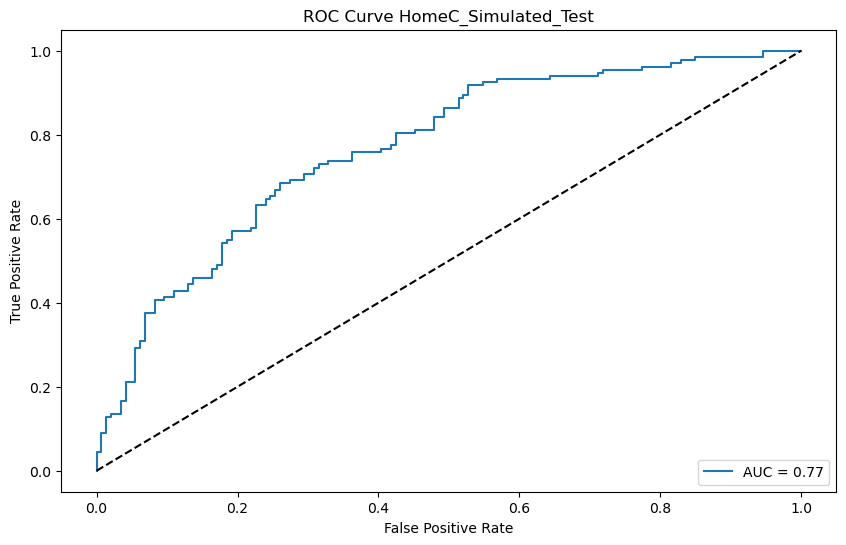

In [82]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeC_sim_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_Anomalies_sim.png',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve HomeC_Simulated_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_ROC_sim.png',bbox_inches='tight')
plt.show()


In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


548/548 [==============================] - 1s 2ms/step
Threshold saved at: 0.016063458389357327
Anomalous Data Indices:
[   44   131   226   475   477   553   867  1300  1537  1670  1709  2001
  2521  3350  3601  4305  4334  4419  4594  4931  4937  4961  5069  5110
  5276  5910  5944  5953  5966  6024  6335  6367  6411  6548  6865  7194
  7280  7433  7547  7897  8032  8439  8847  8891  9526  9720  9776 10383
 10911 10947 11050 11137 11155 11444 12142 12402 12743 12754 13146 13343
 13434 13646 13698 13906 13934 14009 14316 14502 14569 14670 14693 14939
 14958 15042 15196 15222 15226 15624 15726 15731 15874 16829 17380]


In [58]:
test_reconstruction_error

array([0.00055937, 0.00040815, 0.00021097, ..., 0.00192834, 0.0060836 ,
       0.00493025])

In [59]:
y_test

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [60]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5026826484018265
Precision: 0.7831325301204819
Recall: 0.007420091324200913
TNR: 0.9979452054794521
FPR: 0.002054794520547945
FNR: 0.992579908675799
F1 Score: 0.014700893361981228
ROC AUC: 0.6844021574821209


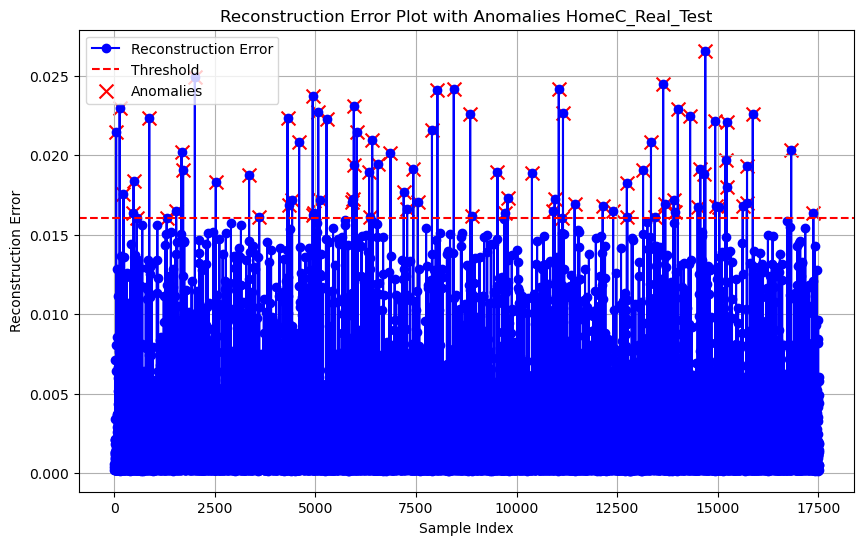

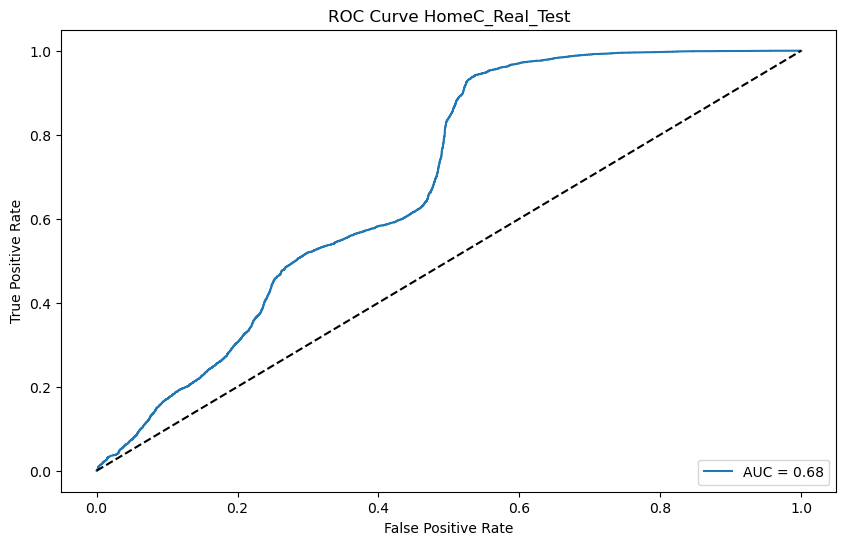

In [61]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeC_Real_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_Anomalies_real.png',bbox_inches='tight')
plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve HomeC_Real_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_ROC_real.png',bbox_inches='tight')
plt.show()


### Model - 2 for Home C (Simulated and Real Test Set)
#### Implementing hidden-dim layers

In [85]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

In [86]:
data_df

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,...,M1371,M1372,M1373,M1374,M1375,M1376,M1377,M1378,M1379,Label
0,461,527,417,417,327,275,276,274,275,274,...,684,684,671,688,685,365,357,320,336,0
1,311,309,462,447,438,440,432,430,423,432,...,675,317,355,356,355,352,502,512,499,0
2,748,749,622,617,644,643,692,699,696,695,...,774,761,761,761,761,764,771,762,745,0
3,407,407,407,402,404,277,279,283,277,307,...,276,276,277,276,278,279,313,276,282,0
4,280,272,282,281,281,279,282,282,281,281,...,405,405,395,403,401,281,280,280,320,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,281,433,431,411,411,417,406,395,412,404,...,626,625,628,624,625,629,625,663,625,0
35036,406,403,406,407,408,422,416,404,400,401,...,381,261,276,259,257,260,259,259,264,0
35037,260,260,262,286,285,288,279,284,250,260,...,467,314,313,317,264,261,266,263,261,0
35038,259,259,260,274,262,403,418,398,390,383,...,390,388,389,388,388,386,386,262,262,0


In [87]:
# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Split the data into training and test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train_scaled shape:", X_train.shape)
#print("y_train shape:", y_train.shape)


X shape: (35040, 1380)
y shape: (35040,)
X_train_scaled shape: (35040, 1380)


In [88]:
X_train_scaled

array([[0.05534523, 0.06724356, 0.04741302, ..., 0.0366757 , 0.02999097,
        0.03288166],
       [0.02830359, 0.02794303, 0.05552551, ..., 0.06287263, 0.06467931,
        0.06233062],
       [0.10708491, 0.10726519, 0.08436993, ..., 0.11147245, 0.10984643,
        0.10677507],
       ...,
       [0.01910943, 0.01910943, 0.01946998, ..., 0.02023487, 0.01969286,
        0.01933153],
       [0.01892915, 0.01892915, 0.01910943, ..., 0.04191509, 0.0195122 ,
        0.0195122 ],
       [0.02920498, 0.0290247 , 0.02866414, ..., 0.00740741, 0.00758808,
        0.03306233]])

In [14]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32  # This is the variable you want to use

input_layer = Input(shape=(input_dim,))
encoder_hidden_layer = Dense(hidden_dim, activation='relu')(input_layer)  # Hidden layer
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(encoder_hidden_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
986/986 [==============================] - 5s 4ms/step - loss: 0.0123 - val_loss: 0.0090
Epoch 2/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0070 - val_loss: 0.0044
Epoch 3/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0033 - val_loss: 0.0027
Epoch 4/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 5/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 6/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 7/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 8/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0018 - val_lo

986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 82/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 83/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 84/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 85/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 86/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 87/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 88/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 89/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 90/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0014 - val_loss: 

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense_4 (Dense)             (None, 32)                44192     
                                                                 
 dense_5 (Dense)             (None, 128)               4224      
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 128)               8320      
                                                                 
 dense_8 (Dense)             (None, 1380)              178020    
                                                                 
Total params: 243,012
Trainable params: 243,012
Non-trainab

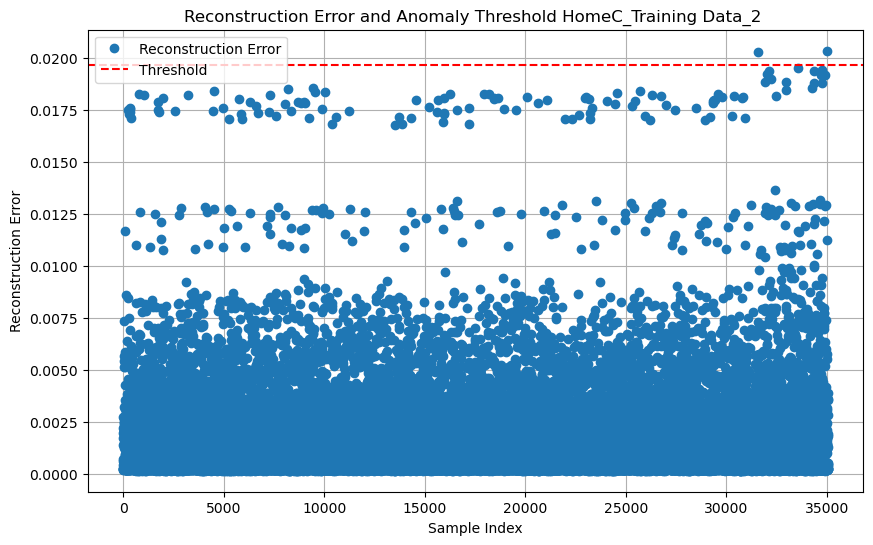

In [26]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (85 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold HomeC_Training Data_2 ')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_Training Data_2.png',bbox_inches='tight')
plt.show()


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


C:\Users\olufe\AppData\Local\Temp\ipykernel_24148\943742418.py:24: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_24148\943742418.py:25: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


9/9 [==============================] - 0s 2ms/step
Threshold saved at: 0.019676005747859576
Anomalous Data Indices:
[ 15  90 113 149 150 157 163 173 232 237]


In [28]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5519713261648745
Precision: 0.9
Recall: 0.06766917293233082
TNR: 0.9931506849315068
FPR: 0.00684931506849315
FNR: 0.9323308270676691
F1 Score: 0.1258741258741259
ROC AUC: 0.7503862395715316


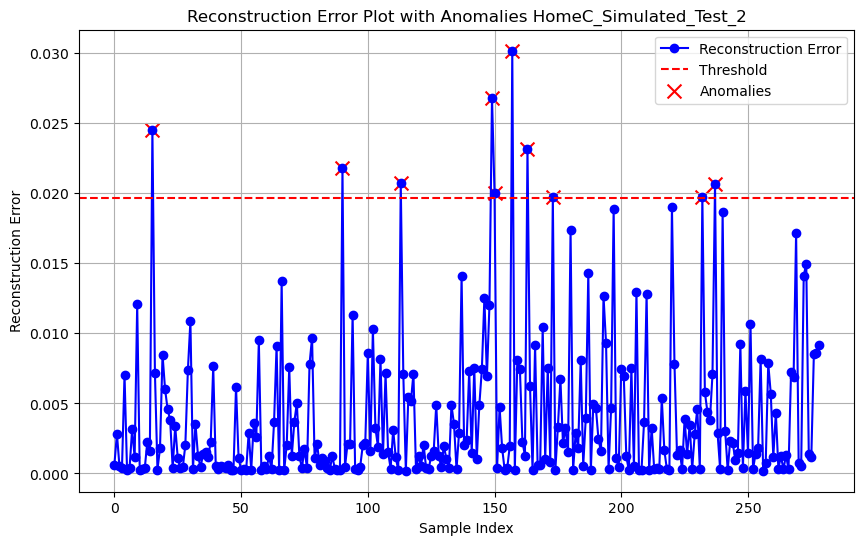

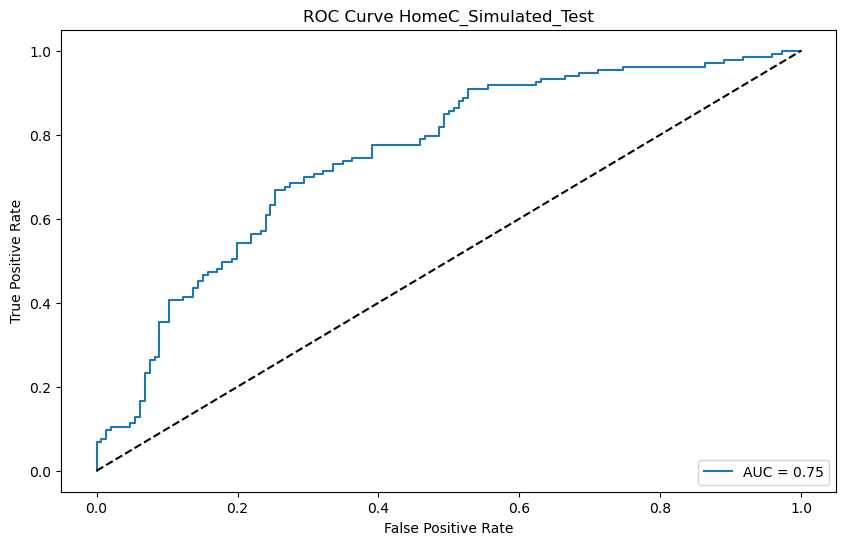

In [29]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeC_Simulated_Test_2')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_Anomalies_sim_2.png',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve HomeC_Simulated_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_ROC_sim_2.png',bbox_inches='tight')
plt.show()


In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


548/548 [==============================] - 1s 2ms/step
Threshold saved at: 0.019676005747859576
Anomalous Data Indices:
[   44   131   226   306   331   477   553   821   867   896  1056  1227
  1544  1670  1709  2001  2282  2521  2899  2981  3350  3351  3365  3448
  3565  3896  4305  4322  4419  4594  4774  4831  4854  4931  5031  5069
  5276  5331  5436  5437  5944  5953  5966  6024  6039  6313  6335  6411
  6414  6520  6548  6658  6865  7086  7190  7433  7787  7897  8032  8091
  8160  8439  8847  9079  9526  9747  9776 10383 10634 10996 11050 11155
 11559 12142 12200 12479 12743 13146 13253 13322 13343 13508 13555 13646
 13698 13786 13906 14009 14316 14546 14670 14693 14939 14993 15039 15196
 15222 15731 15769 15874 16240 16293 16367 16829 17459]


In [31]:
test_reconstruction_error

array([0.00066959, 0.00044362, 0.00024484, ..., 0.00236562, 0.01103104,
       0.00898303])

In [32]:
y_test

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [33]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.502568493150685
Precision: 0.7142857142857143
Recall: 0.008561643835616438
TNR: 0.9965753424657534
FPR: 0.003424657534246575
FNR: 0.9914383561643836
F1 Score: 0.01692047377326565
ROC AUC: 0.6564267060736848


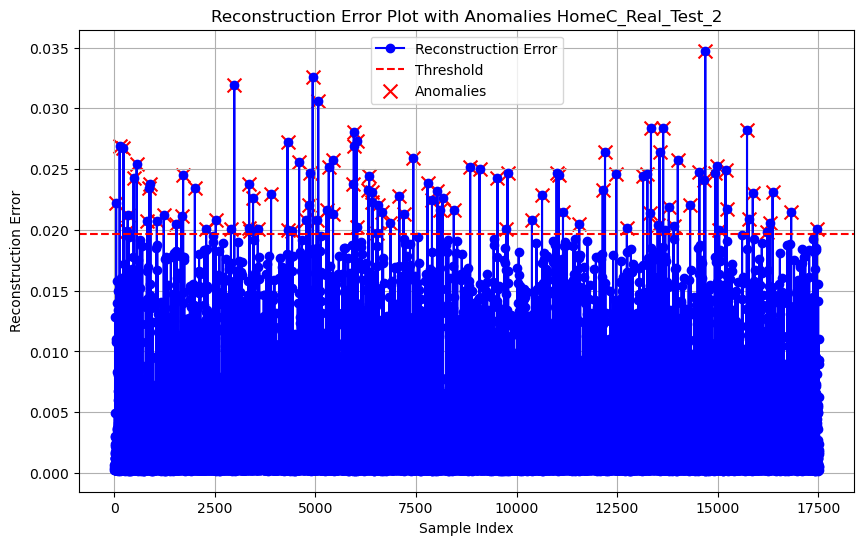

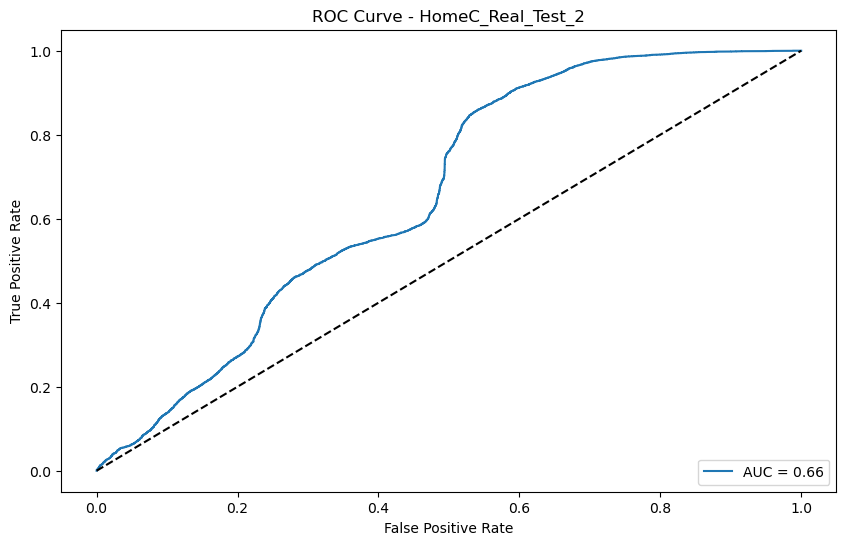

In [34]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeC_Real_Test_2')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_Anomalies_real_2.png',bbox_inches='tight')
plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - HomeC_Real_Test_2')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\mlp-C_ROC_real_2.png',bbox_inches='tight')
plt.show()
